In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
df = pd.read_csv(r"C:\Users\rachi\Downloads\Churn_Modelling.csv")
d1=df.copy()

In [38]:
df.shape

(10000, 14)

In [39]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [41]:
df.drop(['RowNumber','CustomerId','Surname'],axis=1)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [42]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for i in df.columns:
    if df[i].dtype=='object':
        df[i]=le.fit_transform(df[i])

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, 'RowNumber'),
  Text(1, 0, 'CustomerId'),
  Text(2, 0, 'Surname'),
  Text(3, 0, 'CreditScore'),
  Text(4, 0, 'Geography'),
  Text(5, 0, 'Gender'),
  Text(6, 0, 'Age'),
  Text(7, 0, 'Tenure'),
  Text(8, 0, 'Balance'),
  Text(9, 0, 'NumOfProducts'),
  Text(10, 0, 'HasCrCard'),
  Text(11, 0, 'IsActiveMember'),
  Text(12, 0, 'EstimatedSalary'),
  Text(13, 0, 'Exited')])

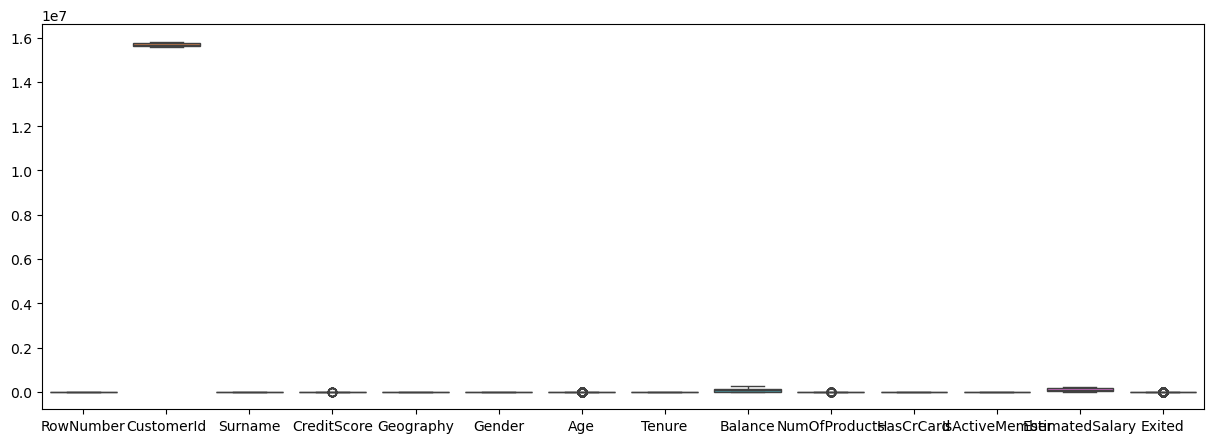

In [43]:
plt.figure(figsize=(15,5))
sns.boxplot(data=df.select_dtypes(include=['int64', 'float64']))
plt.xticks(rotation=0)

In [44]:

d = df[['CreditScore','Age','NumOfProducts']]
for i in d:
    low = df[i].quantile(0.05)
    up = df[i].quantile(0.95)
    df[i]=df[i].clip(low,up)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, 'RowNumber'),
  Text(1, 0, 'CustomerId'),
  Text(2, 0, 'Surname'),
  Text(3, 0, 'CreditScore'),
  Text(4, 0, 'Geography'),
  Text(5, 0, 'Gender'),
  Text(6, 0, 'Age'),
  Text(7, 0, 'Tenure'),
  Text(8, 0, 'Balance'),
  Text(9, 0, 'NumOfProducts'),
  Text(10, 0, 'HasCrCard'),
  Text(11, 0, 'IsActiveMember'),
  Text(12, 0, 'EstimatedSalary'),
  Text(13, 0, 'Exited')])

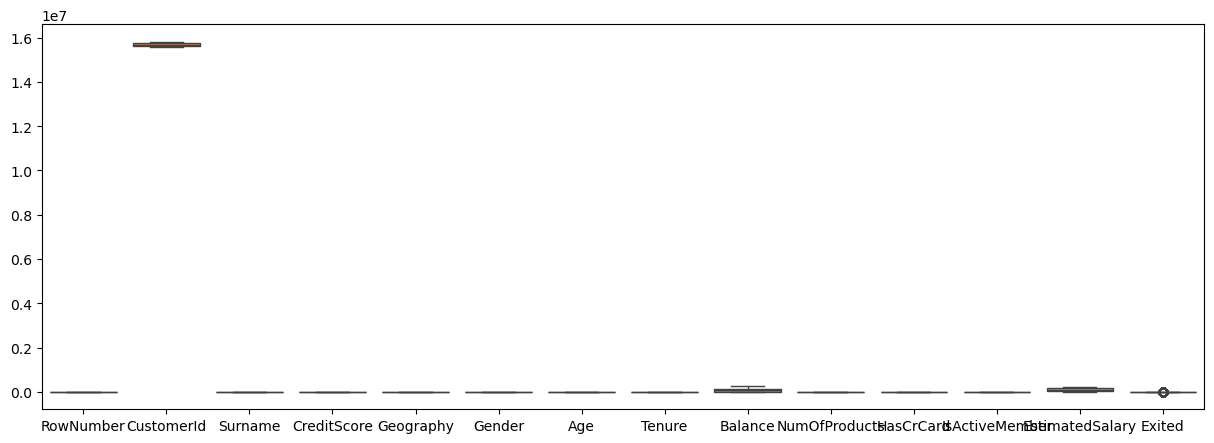

In [45]:
plt.figure(figsize=(15,5))
sns.boxplot(data=df.select_dtypes(include=['int64', 'float64']))
plt.xticks(rotation=0)

In [46]:
X=df.drop('Exited',axis=1)
y=df['Exited']


In [47]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
X = ss.fit_transform(X)

In [48]:
from sklearn.naive_bayes import GaussianNB
gb = GaussianNB()

In [49]:
from sklearn.model_selection import train_test_split
Xt,Xte,yt,yte=train_test_split(X,y,test_size=0.2,random_state=42)

In [50]:
gb.fit(Xt,yt)

,priors,None
,var_smoothing,1e-09


In [51]:
yp=gb.predict(Xte)

In [52]:
from sklearn.metrics import classification_report as cr
print(cr(yte,yp))

              precision    recall  f1-score   support

           0       0.85      0.95      0.89      1607
           1       0.58      0.30      0.39       393

    accuracy                           0.82      2000
   macro avg       0.71      0.62      0.64      2000
weighted avg       0.79      0.82      0.80      2000

